# Pipeline do ICR — passo a passo

Este notebook executa **todas as etapas** do projeto, uma a uma, com
explicações, para você entender o que acontece em cada ponto. Ele reutiliza os
dados já coletados em `data/` (rápido); a Etapa 1 mostra a *mecânica* da coleta
em amostras pequenas, sem esperar os ~10 min do `01_coletar.py`.

**Roteiro:**
0. Preparação · 1. Coleta (SGS + IF.Data + nomes) · 2. Indicadores CAMELS ·
3. Padronização + ICR · 4. Validação temporal · 5. Validação macro ·
6. Validação com ações (B3) · 7. Explicabilidade · 8. Alerta precoce (EWS) ·
9. Grandes bancos com Basileia · 10. Diagnóstico.

Dica: rode as células em ordem (Shift+Enter).

## 0. Preparação

Carregamos o pacote `icr` (em `../src`) e a configuração (`config/indicadores.yaml`).
Se sua rede corporativa der erro de certificado SSL, **descomente** a linha do
`ICR_VERIFY_SSL` antes de tudo (ou instale `truststore`).

In [1]:
import os, sys
# os.environ['ICR_VERIFY_SSL'] = 'false'   # <- descomente SÓ se der erro de SSL
sys.path.insert(0, '../src')

# Recarrega os módulos 'icr' do disco. Rode esta célula depois de editar o
# código-fonte para o kernel usar a versão nova (evita o erro
# "module 'icr.x' has no attribute ..." quando se edita com o notebook aberto).
import importlib
for _m in ['http','config','sgs','ifdata','nomes','indicadores','score',
           'validacao','explicabilidade','acoes','distress','portal','relatorio','icr2']:
    try: importlib.reload(importlib.import_module(f'icr.{_m}'))
    except Exception: pass

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

from icr import (sgs, ifdata, nomes as mod_nomes, indicadores as ind, score,
                 validacao, explicabilidade as expl, acoes, distress, portal)
from icr.config import (carregar_config, DIR_RAW, dir_raw_painel,
                        dir_processed_painel)
from icr.http import criar_sessao

cfg = carregar_config()
sessao = criar_sessao()
pd.set_option('display.max_columns', 30, 'display.width', 160)
print('Painéis:', [p['nome'] for p in cfg['paineis']])
print('Indicadores do ICR:', list(cfg['indicadores']))
print('Janela:', cfg['coleta']['periodos_auto'])

Painéis: ['prudencial', 'sistemico']
Indicadores do ICR: ['basileia', 'alavancagem', 'roa', 'roe', 'imobilizacao', 'liquidez', 'eficiencia']
Janela: {'inicio': 201603, 'fim': 202412}


## 1. Etapa 1 — Coleta de dados

Três fontes públicas do BCB: **SGS** (séries macro), **IF.Data** (indicadores
por instituição) e o **portal IF.Data** (nomes). Vamos ver a mecânica de cada uma.

### 1.1 SGS — séries macroeconômicas

API REST simples. Cada série tem um código (ex.: 21082 = inadimplência total).
Baixamos uma série, depois trimestralizamos para casar com o IF.Data.

Inadimplência total — últimos pontos:


,data,valor
127,2025-08-01,4.14
128,2025-09-01,4.09
129,2025-10-01,4.18
130,2025-11-01,4.23
131,2025-12-01,4.20


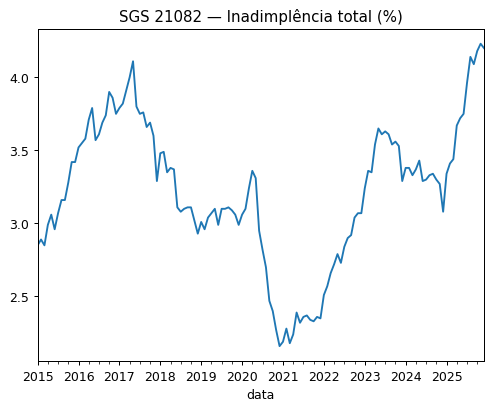

In [2]:
inad = sgs.baixar_serie(21082, cfg['coleta']['sgs_data_inicial'], cfg['coleta']['sgs_data_final'], sessao=sessao)
print('Inadimplência total — últimos pontos:')
display(inad.tail())
inad.plot(x='data', y='valor', title='SGS 21082 — Inadimplência total (%)', legend=False);

In [3]:
# Baixa TODAS as séries do config e trimestraliza (formato largo por AnoMes)
sgs_longo = sgs.baixar_varias(cfg['sgs_series'], cfg['coleta']['sgs_data_inicial'], cfg['coleta']['sgs_data_final'], sessao=sessao)
sgs_trim = sgs.trimestralizar(sgs_longo, como='last')
display(sgs_trim.tail())

serie,AnoMes,icc_total,inadimplencia_pf,inadimplencia_pj,inadimplencia_total,ipca_mensal,selic_mensal,spread_pf,spread_pj,spread_total
39,202412,68.97,3.63,2.21,3.08,0.52,0.93,8.56,27.16,17.62
40,202503,64.72,4.03,2.49,3.44,0.56,0.96,9.75,29.87,19.55
41,202506,53.58,4.41,2.67,3.75,0.24,1.10,10.91,32.34,20.74
42,202509,52.25,4.89,2.77,4.09,0.48,1.22,10.96,32.10,20.53
43,202512,60.48,5.12,2.68,4.20,0.33,1.22,10.36,33.30,21.01


### 1.2 IF.Data (Olinda) — indicadores por instituição

A API devolve os dados em **formato longo** (uma linha por instituição × coluna).
Nós pivotamos para **formato largo** (uma linha por instituição). Repare que
`Relatorio` é o *número* do relatório: 1=Resumo, 2=Ativo, 4=DRE.

In [4]:
display(ifdata.listar_relatorios(sessao))  # relatórios disponíveis

,NomeRelatorio,NumeroRelatorio
0,Resumo,1
1,Ativo,2
2,Passivo,3
3,Demonstração de Resultado,4
4,Informações de Capital,5
5,Segmentação,6
6,Carteira de Crédito Ativa - Por indexador,7
7,Carteira de crédito ativa - por nível de risco...,8
8,Carteira de crédito ativa - por região geográfica,9
9,Carteira de crédito ativa - quantidade de clie...,10


In [5]:
# Um relatório, um trimestre, tipo 3 (individual) — formato LONGO
longo = ifdata.baixar_valores(ano_mes=202412, tipo_instituicao=3, relatorio=1, sessao=sessao)
print('Formato longo (uma linha por instituição × coluna):')
display(longo.head())

# Pivot para LARGO (uma linha por instituição)
largo = ifdata.relatorio_largo(longo)
print('Formato largo — colunas do Resumo:', [c for c in largo.columns if c not in ('AnoMes','CodInst')])
display(largo.head())

Formato longo (uma linha por instituição × coluna):


,TipoInstituicao,CodInst,AnoMes,NomeRelatorio,NumeroRelatorio,Grupo,Conta,NomeColuna,DescricaoColuna,Saldo
0,3,00000000,202412,Resumo,1,None,78182,Ativo Total,[10000007] + [20000004],2.304112e+12
1,3,00000000,202412,Resumo,1,None,78183,Carteira de Crédito Classificada,[31000000],1.035355e+12
2,3,00000000,202412,Resumo,1,None,78184,Passivo Circulante e Exigível a Longo Prazo e ...,[40000008] + [50000005],2.123233e+12
3,3,00000000,202412,Resumo,1,None,78185,Captações,[41000007] + [42000006] + [43000005] + [46000002],1.823966e+12
4,3,00000000,202412,Resumo,1,None,78186,Patrimônio Líquido,[60000002] + [70000009]+ [80000006],1.808785e+11


Formato largo — colunas do Resumo: ['Ativo Total', 'Captações', 'Carteira de Crédito Classificada', 'Lucro Líquido', 'Passivo Circulante e Exigível a Longo Prazo e Resultados de Exercícios Futuros', 'Patrimônio Líquido']


,AnoMes,CodInst,Ativo Total,Captações,Carteira de Crédito Classificada,Lucro Líquido,Passivo Circulante e Exigível a Longo Prazo e Resultados de Exercícios Futuros,Patrimônio Líquido
0,202412,00000000,2.304112e+12,1.823966e+12,1.035355e+12,1.759040e+10,2.123233e+12,1.808785e+11
1,202412,00000208,6.100236e+10,5.190967e+10,3.676708e+10,1.879959e+08,5.731503e+10,3.687331e+09
2,202412,00066670,4.198040e+08,0.000000e+00,0.000000e+00,1.692836e+07,2.019622e+08,2.178418e+08
3,202412,00068987,6.132644e+08,3.424317e+08,3.381977e+08,2.711131e+06,5.356235e+08,7.764087e+07
4,202412,00075847,3.156067e+09,2.697887e+09,1.687751e+09,2.048862e+07,2.867478e+09,2.885884e+08


### 1.3 Nomes das instituições

O cadastro oficial (Olinda) está com erro 500, então pegamos os nomes do backend
de arquivos do portal (mapeando `CodInst → nome`). Aqui carregamos o que já foi
salvo; para rebaixar, use `mod_nomes.baixar_nomes(sessao)`.

In [6]:
cam_nomes = DIR_RAW / 'nomes_instituicoes.parquet'
nomes = pd.read_parquet(cam_nomes) if cam_nomes.exists() else mod_nomes.baixar_nomes(sessao)
print(f'{len(nomes)} instituições com nome')
display(nomes.head())

2341 instituições com nome


,CodInst,nome,segmento,controle,fonte_cadastro
0,00010045,BRADESCO,Conglomerado,Privado nacional,202603
1,00010069,ITAU,Conglomerado,Privado nacional,202603
2,00010083,SAFRA,Conglomerado,Privado nacional,202603
3,00020107,JP MORGAN CHASE,Conglomerado,Estrangeiro,202603
4,00020152,MERCANTIL DO BRASIL,Conglomerado,Privado nacional,202603


### 1.4 Coleta completa

Os passos acima, repetidos para 36 trimestres, 2 painéis e 3 relatórios, são o
que o script `01_coletar.py` faz. O resultado fica em `data/raw/<painel>/`.
A célula abaixo verifica se os dados já existem (evita reesperar a coleta).

In [7]:
PAINEL = 'sistemico'   # troque para 'prudencial' para ver o outro painel
raw = dir_raw_painel(PAINEL)
faltando = [f'ifdata_rel{r}.parquet' for r in (1,2,4) if not (raw/f'ifdata_rel{r}.parquet').exists()]
if faltando:
    print('Dados ausentes:', faltando, '\n>>> rode antes:  python scripts/01_coletar.py')
else:
    rel1 = pd.read_parquet(raw/'ifdata_rel1.parquet')
    rel2 = pd.read_parquet(raw/'ifdata_rel2.parquet')
    rel4 = pd.read_parquet(raw/'ifdata_rel4.parquet')
    print(f"Painel '{PAINEL}': {rel1.AnoMes.nunique()} trimestres, {len(rel1)} linhas no Resumo")

Painel 'sistemico': 36 trimestres, 54787 linhas no Resumo


## 2. Etapa 2 — Indicadores CAMELS

A partir dos relatórios brutos, calculamos os indicadores prudenciais. Repare na
**anualização semestral** do ROA/ROE (o resultado do IF.Data acumula por semestre)
e no filtro de porte (Ativo ≥ R$ 1 bi).

In [8]:
df_ind = ind.construir_indicadores(rel1, rel2, rel4)
df_ind = ind.aplicar_filtro(df_ind,
                            cfg['filtro_instituicoes']['ativo_total_minimo_mil'],
                            cfg['filtro_instituicoes']['exigir_basileia'])
df_ind = df_ind.merge(nomes[['CodInst','nome']], on='CodInst', how='left')
df_ind['nome'] = df_ind['nome'].fillna(df_ind['CodInst'])

# Maiores bancos no trimestre mais recente
ult = df_ind.AnoMes.max()
cols = ['nome','basileia','alavancagem','roa','roe','liquidez','eficiencia','ativo_total_mil']
cols = [c for c in cols if c in df_ind.columns]
display(df_ind[df_ind.AnoMes==ult].sort_values('ativo_total_mil', ascending=False)[cols].head(8).round(2))

  [aviso] Basileia indisponível neste universo (tipo != 1); filtro de Basileia ignorado. Capital será representado pela alavancagem.


  Filtro de instituições: 54787 -> 52994 (ativo >= R$ 1.0 bi)


,nome,basileia,alavancagem,roa,roe,liquidez,eficiencia,ativo_total_mil
51440,BANCO DO BRASIL S.A.,NaN,12.74,1.53,19.45,40.89,60.20,2.304112e+12
52715,ITAÚ UNIBANCO S.A.,NaN,12.55,1.29,16.23,49.53,64.31,2.090515e+12
51457,CAIXA ECONOMICA FEDERAL,NaN,19.49,0.72,14.07,26.40,59.81,2.026392e+12
52716,BANCO BRADESCO S.A.,NaN,10.47,1.21,12.66,41.62,89.32,1.679912e+12
52954,BANCO SANTANDER (BRASIL) S.A.,NaN,14.03,1.10,15.44,35.64,125.90,1.264471e+12
52333,BANCO NACIONAL DE DESENVOLVIMENTO ECONOMICO E ...,NaN,5.28,3.12,16.48,23.60,7.47,8.359280e+11
52267,BANCO BTG PACTUAL S.A.,NaN,8.41,2.56,21.55,58.72,66.76,4.830908e+11
52721,ITAÚ UNIBANCO HOLDING S.A.,NaN,2.17,8.77,19.04,10.26,41.00,4.389113e+11


## 3. Etapa 3 — Padronização (escore-z) + ICR

Cada indicador vira um **escore-z dentro do trimestre** (média 0, desvio 1). O
ICR é a soma ponderada: `ICR = Σ peso·sinal·z`. A zona de risco é o decil inferior.

In [9]:
df_padr = score.padronizar(df_ind, cfg['indicadores'], cfg['padronizacao'])
df_icr = score.calcular_icr(df_padr, cfg['indicadores'], cfg.get('orientacao','solidez'))
df_icr = score.classificar_risco(df_icr, cfg['zona_risco']['percentil'], cfg.get('orientacao','solidez'))

# Verificação: o escore-z tem média ~0 e desvio ~1 por trimestre?
z = f"z_roe"
print('Checagem da padronização (deve ser ~0 e ~1):')
print('  média de', z, '=', round(df_icr.groupby('AnoMes')[z].mean().abs().max(), 8))
print('  desvio de', z, '=', round(df_icr.groupby('AnoMes')[z].std(ddof=0).median(), 4))

Checagem da padronização (deve ser ~0 e ~1):
  média de z_roe = 0.0
  desvio de z_roe = 1.0


In [10]:
# Ranking do trimestre mais recente
rk = df_icr[df_icr.AnoMes==ult].sort_values('ICR', ascending=False)
vis = ['nome','ICR','faixa','roe','liquidez','eficiencia','ativo_total_mil']
vis = [c for c in vis if c in rk.columns]
print('TOP 5 mais sólidos:'); display(rk[vis].head(5).round(2))
print('5 na zona de risco:'); display(rk[vis].tail(5).round(2))

TOP 5 mais sólidos:


,nome,ICR,faixa,roe,liquidez,eficiencia,ativo_total_mil
52482,CAIXA DISTRIBUIDORA DE TÍTULOS E VALORES MOBIL...,1.24,Sólido,124.48,96.43,6.67,1.186747e+09
52010,EAGLE INSTITUICAO DE PAGAMENTO LTDA.,1.20,Sólido,138.52,87.62,2.46,9.401639e+07
52339,ABC BRASIL DISTRIBUIDORA DE TÍTULOS E VALORES ...,1.19,Sólido,142.72,88.42,10.81,7.534373e+07
52484,GETNET SOCIEDADE DE CREDITO DIRETO S.A.,1.19,Sólido,100.59,96.04,0.88,1.117938e+08
52275,BB GESTÃO DE RECURSOS - DISTRIBUIDORA DE TÍTUL...,1.17,Sólido,145.63,87.49,6.82,4.077799e+09


5 na zona de risco:


,nome,ICR,faixa,roe,liquidez,eficiencia,ativo_total_mil
52540,MAGNUM SOCIEDADE DE CRÉDITO DIRETO S.A.,-2.19,Crítico,-324.91,32.86,1001.49,5089743.81
52105,REMITLY CORRETORA DE CÂMBIO LTDA.,-2.22,Crítico,-762.37,98.79,286820.59,1050050.63
52642,SANTS SOCIEDADE DE CRÉDITO DIRETO S.A.,-2.28,Crítico,-494.79,92.16,5896.97,1117612.90
52463,FIDO SOCIEDADE DE EMPRÉSTIMO ENTRE PESSOAS S.A.,-2.59,Crítico,-430.81,4.29,2261.98,1338476.73
52524,LEND INSTITUICAO DE PAGAMENTO LTDA,-2.71,Crítico,-271.94,0.09,47521.24,1071153.39


Decomposição do ICR de: CAIXA DISTRIBUIDORA DE TÍTULOS E VALORES MOBILIÁRIOS S.A.  (ICR=1.237)


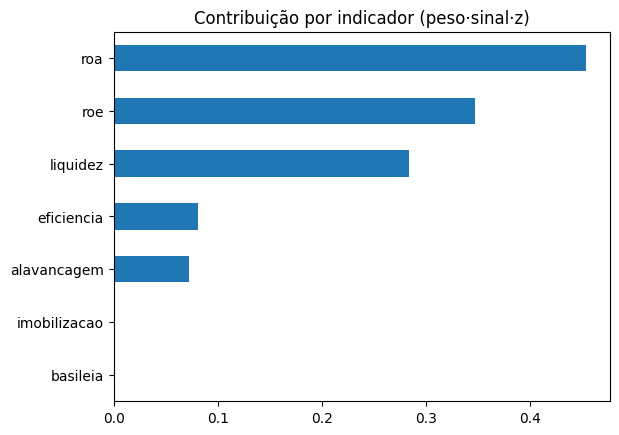

In [11]:
# Decomposição: quanto cada indicador contribuiu para o ICR de UM banco
banco = rk.iloc[0]
contribs = {k: banco.get(f'contrib_{k}') for k in cfg['indicadores'] if f'contrib_{k}' in rk.columns}
print(f"Decomposição do ICR de: {banco['nome']}  (ICR={banco['ICR']:.3f})")
pd.Series(contribs).sort_values().plot.barh(title='Contribuição por indicador (peso·sinal·z)');

## 4. Etapa 4 — Validação temporal

O ICR médio do sistema (ponderado por ativo) deve acompanhar o ciclo econômico.
A **média simples é sempre 0** (identidade do escore-z), por isso plotamos a
ponderada e a **mediana**.

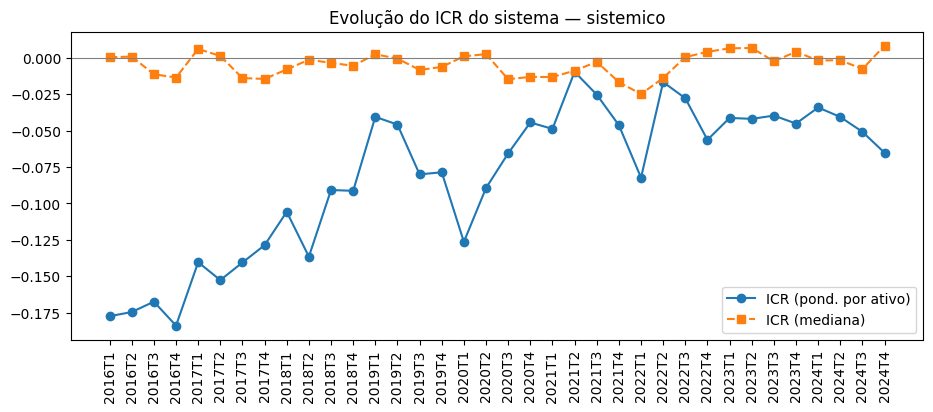

In [12]:
serie = validacao.serie_sistema(df_icr, ponderar_por_ativo=True)
x = [f'{a//100}T{(a%100)//3}' for a in serie.AnoMes]
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(x, serie.ICR_medio_ponderado, 'o-', label='ICR (pond. por ativo)')
ax.plot(x, serie.ICR_mediana, 's--', label='ICR (mediana)')
ax.axhline(0, color='grey', lw=.8); ax.legend(); ax.tick_params(axis='x', rotation=90)
ax.set_title(f'Evolução do ICR do sistema — {PAINEL}'); plt.show()

## 5. Etapa 5 — Validação macroeconômica

Correlacionamos o ICR do sistema com as séries do SGS. Espera-se sinal
**negativo** com inadimplência e spread (sistema mais sólido ⇒ menos risco macro).

,serie_macro,pearson,spearman,n
6,spread_pf,-0.818,-0.646,36
7,spread_pj,-0.709,-0.517,36
2,inadimplencia_pj,-0.699,-0.613,36
3,inadimplencia_total,-0.618,-0.535,36
8,spread_total,-0.562,-0.387,36
1,inadimplencia_pf,-0.515,-0.382,36
5,selic_mensal,-0.218,-0.163,36
0,icc_total,0.175,0.167,36
4,ipca_mensal,0.211,0.232,36


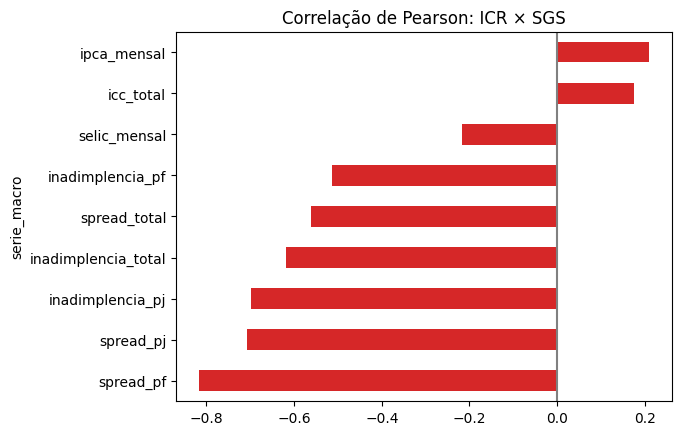

In [13]:
macro = pd.read_parquet(DIR_RAW/'sgs_trimestral.parquet')
corr = validacao.correlacao_macro(serie, macro)
display(corr.round(3))
corr.set_index('serie_macro')['pearson'].sort_values().plot.barh(
    color='tab:red', title='Correlação de Pearson: ICR × SGS'); plt.axvline(0, color='grey');

## 6. Etapa 6 — Validação com ações (B3)

Cruzamos o ICR dos bancos listados com o preço das ações (Yahoo Finance).
Espera-se correlação **positiva** entre ICR e preço.

In [14]:
cot = acoes.baixar_cotacoes(cfg['acoes']['tickers'], cfg['acoes']['sufixo_yahoo'],
                            cfg['acoes']['range'], cfg['acoes']['intervalo'], sessao=sessao)
acoes_trim = acoes.trimestralizar(cot)
display(acoes.correlacionar(df_icr, acoes_trim).round(3))

  ITUB4 (60701190): 42 cotações
  BBDC4 (60746948): 42 cotações


  BBAS3 (00000000): 42 cotações


  SANB11 (90400888): 42 cotações
  BPAC11 (30306294): 39 cotações


,ticker,n,corr_ICR_preco,corr_dICR_retorno
0,BBAS3,34,0.464,0.369
1,BBDC4,34,0.333,0.241
2,BPAC11,32,0.381,0.131
3,ITUB4,34,0.233,0.091
4,SANB11,34,0.522,0.176


## 7. Etapa 7 — Explicabilidade

Duas visões: a **decomposição exata** (o ICR é linear) e o **SHAP** sobre um
modelo que prevê a zona de risco (demonstração da técnica).

In [15]:
imp = expl.importancia_por_contribuicao(df_icr, cfg['indicadores'])
display(imp.round(3))
_, shap_resumo = expl.shap_zona_risco(df_icr, cfg['indicadores'])
display(shap_resumo)

,indicador,contrib_abs_media,contrib_media,importancia_pct
0,liquidez,0.128,-0.0,33.267
1,roe,0.067,0.0,17.434
2,alavancagem,0.066,0.0,17.156
3,roa,0.065,-0.0,16.931
4,eficiencia,0.059,-0.0,15.212
5,basileia,0.000,0.0,0.000
6,imobilizacao,0.000,0.0,0.000


C:\Users\ahmad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,indicador,shap_abs_medio
0,roa,0.754362
1,liquidez,0.715570
2,roe,0.678160
3,eficiencia,0.623679
4,alavancagem,0.452280


## 8. Etapa 8 — Modelo de Alerta Precoce (EWS)

Prevê **distress futuro** (Basileia < 10,5% ou ROE < −30% em até 4 trimestres) a
partir dos indicadores atuais. Usa o painel **prudencial** (tem Basileia) e
validação fora do tempo (treina no passado, testa no futuro).

In [16]:
# Indicadores do painel prudencial (tem Basileia)
rp = dir_raw_painel('prudencial')
ip = ind.construir_indicadores(pd.read_parquet(rp/'ifdata_rel1.parquet'),
                               pd.read_parquet(rp/'ifdata_rel2.parquet'),
                               pd.read_parquet(rp/'ifdata_rel4.parquet'))
ip = ind.aplicar_filtro(ip, cfg['filtro_instituicoes']['ativo_total_minimo_mil'], True)
ip = ip.merge(nomes[['CodInst','nome']], on='CodInst', how='left')
ip['nome'] = ip['nome'].fillna(ip['CodInst'])

dd = cfg['distress']
d = distress.marcar_distress(ip, dd['basileia_min'], dd['roe_min'], dd['horizonte'])
print(f"Taxa-base de distress futuro: {d[d['horizonte_observavel']]['alvo'].mean():.2%}")
res = distress.treinar_avaliar(d)
teste = res['teste']
print('Importância das variáveis:')
display(res['importancias'].round(3))

  Filtro de instituições: 32843 -> 31814 (ativo >= R$ 1.0 bi)
Taxa-base de distress futuro: 5.04%


Importância das variáveis:


,feature,importancia
0,roe,0.551
1,roa,0.119
2,eficiencia,0.088
3,basileia,0.075
4,imobilizacao,0.068
5,liquidez,0.063
6,alavancagem,0.036


In [17]:
# SHAP (nao circular: alvo externo ao ICR) + justificativa dos hiperparametros
shap_imp = distress.importancia_shap(res)
if shap_imp is not None:
    print('Importancia SHAP (|valor| medio) do EWS:'); display(shap_imp.round(3))
tun = distress.tunar_hiperparametros(d)
print(f"default: AUC={tun['default']['auc']:.3f} KS={tun['default']['ks']:.3f}")
print(f"tuned  : AUC={tun['tuned']['auc']:.3f} KS={tun['tuned']['ks']:.3f}  cfg={tun['tuned']['cfg']}")
print(f"ganho do tuning: dAUC={tun['tuned']['auc']-tun['default']['auc']:+.4f} -> defaults justificados")

Importancia SHAP (|valor| medio) do EWS:


      feature  shap_abs_medio  shap_pct
0  eficiencia           0.370    29.426
1         roe           0.235    18.715
2         roa           0.175    13.909
3 imobilizacao          0.167    13.279
4    liquidez           0.143    11.384
5    basileia           0.104     8.314
6 alavancagem          0.063     4.973

default: AUC=0.832 KS=0.521
tuned  : AUC=0.828 KS=0.512  cfg={'n_estimators': 50, 'learning_rate': 0.02, 'max_depth': 3, 'subsample': 0.7, 'min_samples_leaf': 20}
ganho do tuning: dAUC=-0.0047 -> defaults justificados

### 8.1 Avaliação do classificador (eventos raros)

Como só ~5% das instituições entram em distress, **acurácia não serve** (prever
"ninguém quebra" acerta 95% e é inútil). Usamos métricas próprias para dados
desbalanceados:

- **AUC-ROC** — separa quem quebra de quem não quebra (0,5 = acaso).
- **AUC-PR** — precisão média; referência é a taxa-base (~0,05).
- **KS** (padrão em *credit scoring*) — máxima separação entre as distribuições
  de escore dos dois grupos; acima de 0,3 já é considerado bom.
- **Matriz de confusão** e **precisão/recall/F1** num ponto de corte.
- **Lift / curva de ganho** — valor operacional da *watchlist*.

AUC-ROC = 0.832   AUC-PR = 0.339   KS = 0.521   (taxa-base = 0.044)


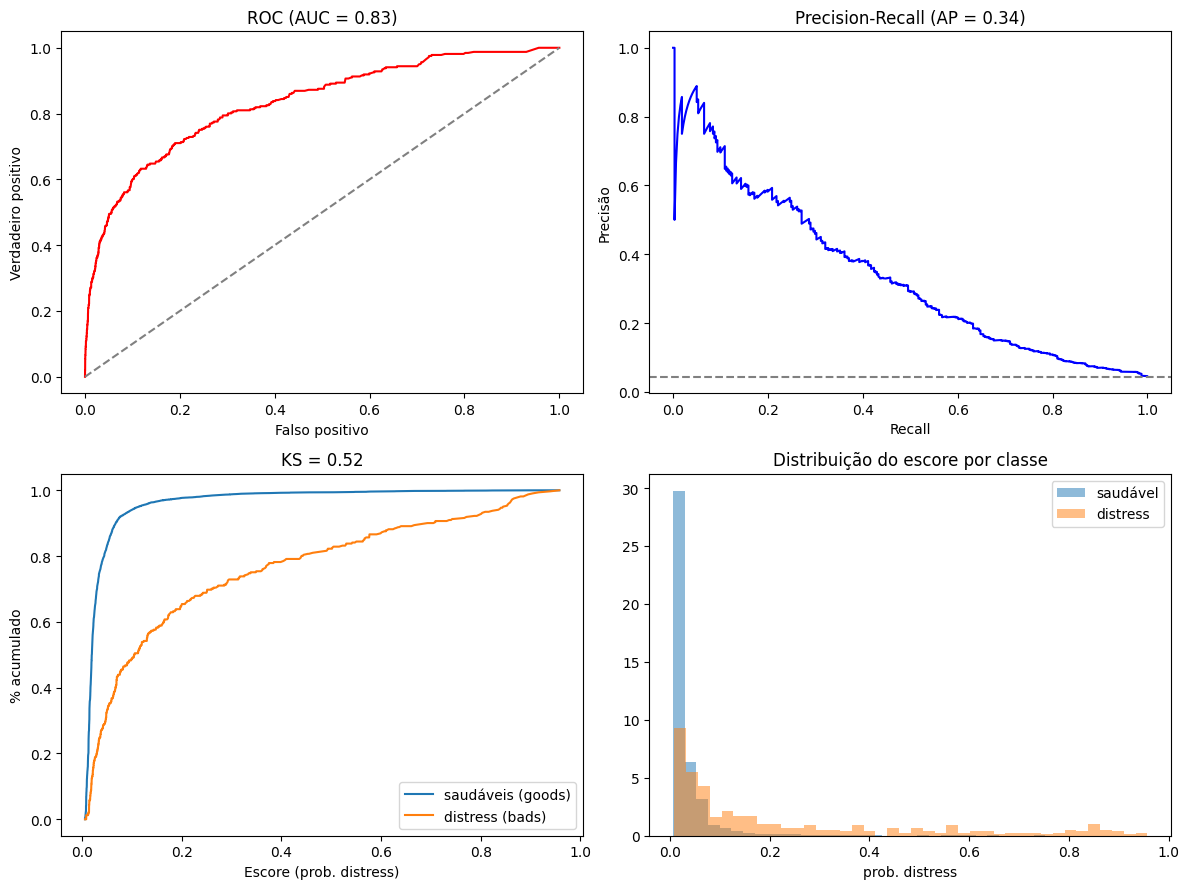

In [17]:
from sklearn.metrics import roc_curve, precision_recall_curve
av = distress.avaliar_classificacao(teste)
print(f"AUC-ROC = {av['auc_roc']:.3f}   AUC-PR = {av['auc_pr']:.3f}   "
      f"KS = {av['ks']:.3f}   (taxa-base = {av['taxa_base']:.3f})")

y = teste['alvo'].to_numpy(); p = teste['prob_distress'].to_numpy()
fpr, tpr, thr = roc_curve(y, p)
prec, rec, _ = precision_recall_curve(y, p)
srt = pd.DataFrame({'y': y, 'p': p}).sort_values('p').reset_index(drop=True)
srt['cum_bad'] = (srt.y == 1).cumsum() / (srt.y == 1).sum()
srt['cum_good'] = (srt.y == 0).cumsum() / (srt.y == 0).sum()

fig, ax = plt.subplots(2, 2, figsize=(12, 9))
ax[0,0].plot(fpr, tpr, 'r'); ax[0,0].plot([0,1],[0,1],'--',color='grey')
ax[0,0].set_title(f"ROC (AUC = {av['auc_roc']:.2f})"); ax[0,0].set_xlabel('Falso positivo'); ax[0,0].set_ylabel('Verdadeiro positivo')
ax[0,1].plot(rec, prec, 'b'); ax[0,1].axhline(av['taxa_base'], ls='--', color='grey')
ax[0,1].set_title(f"Precision-Recall (AP = {av['auc_pr']:.2f})"); ax[0,1].set_xlabel('Recall'); ax[0,1].set_ylabel('Precisão')
ax[1,0].plot(srt.p, srt.cum_good, label='saudáveis (goods)'); ax[1,0].plot(srt.p, srt.cum_bad, label='distress (bads)')
ax[1,0].set_title(f"KS = {av['ks']:.2f}"); ax[1,0].set_xlabel('Escore (prob. distress)'); ax[1,0].set_ylabel('% acumulado'); ax[1,0].legend()
ax[1,1].hist(p[y==0], bins=40, density=True, alpha=.5, label='saudável'); ax[1,1].hist(p[y==1], bins=40, density=True, alpha=.5, label='distress')
ax[1,1].set_title('Distribuição do escore por classe'); ax[1,1].set_xlabel('prob. distress'); ax[1,1].legend()
plt.tight_layout(); plt.show()

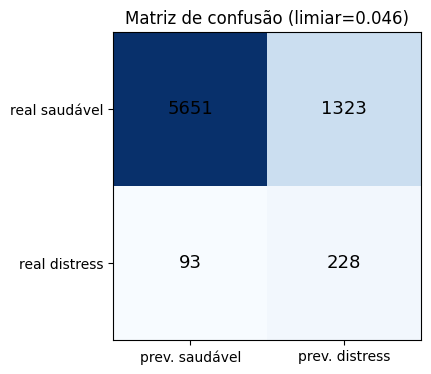

              precision    recall  f1-score   support

    saudável       0.98      0.81      0.89      6974
    distress       0.15      0.71      0.24       321

    accuracy                           0.81      7295
   macro avg       0.57      0.76      0.57      7295
weighted avg       0.95      0.81      0.86      7295

No corte: recall=0.71 (pega 71% dos distress), precisão=0.15. Recall alto e precisão baixa é o esperado
para triagem de eventos raros: melhor sinalizar demais do que perder um caso.


In [18]:
# Matriz de confusão + relatório no limiar de Youden (ponto do KS)
from sklearn.metrics import classification_report
cm = av['matriz_confusao']
fig, ax = plt.subplots(figsize=(4.6, 4))
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=13)
ax.set_xticks([0,1]); ax.set_xticklabels(['prev. saudável','prev. distress'])
ax.set_yticks([0,1]); ax.set_yticklabels(['real saudável','real distress'])
ax.set_title(f"Matriz de confusão (limiar={av['limiar']:.3f})"); plt.show()

pred = (p >= av['limiar']).astype(int)
print(classification_report(y, pred, target_names=['saudável','distress'], zero_division=0))
print(f"No corte: recall={av['recall']:.2f} (pega {av['recall']:.0%} dos distress), "
      f"precisão={av['precisao']:.2f}. Recall alto e precisão baixa é o esperado\n"
      f"para triagem de eventos raros: melhor sinalizar demais do que perder um caso.")

,grupo,n,positivos,taxa_distress,lift,captura_acum
0,1,730,177,0.242,5.510,0.551
1,2,729,41,0.056,1.278,0.679
2,3,730,31,0.042,0.965,0.776
3,4,729,15,0.021,0.468,0.822
4,5,730,16,0.022,0.498,0.872
5,6,729,14,0.019,0.436,0.916
6,7,729,9,0.012,0.281,0.944
7,8,730,12,0.016,0.374,0.981
8,9,729,2,0.003,0.062,0.988
9,10,730,4,0.005,0.125,1.000


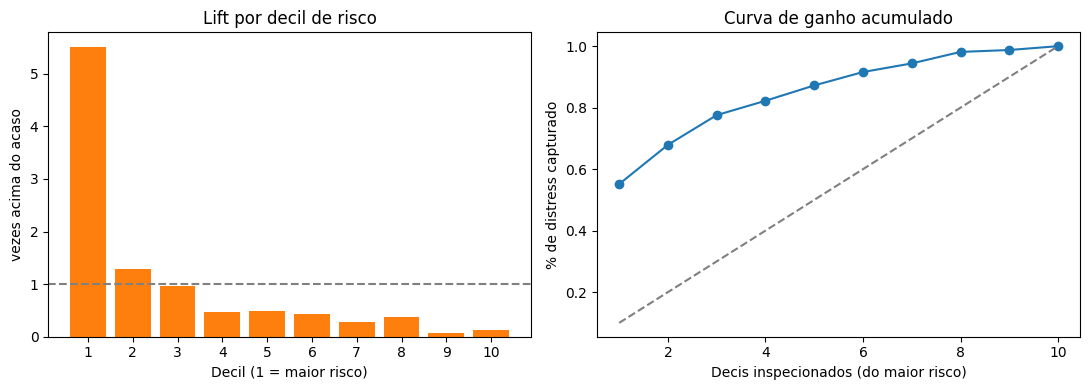

Inspecionando o decil de maior risco (10% das instituições) captura-se 55% de todos os casos de distress.


In [19]:
# Lift e curva de ganho: valor de usar a watchlist
ganho = distress.tabela_ganho(teste['alvo'], teste['prob_distress'])
display(ganho.round(3))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(ganho.grupo.astype(str), ganho.lift, color='tab:orange'); ax[0].axhline(1, ls='--', color='grey')
ax[0].set_title('Lift por decil de risco'); ax[0].set_xlabel('Decil (1 = maior risco)'); ax[0].set_ylabel('vezes acima do acaso')
ax[1].plot(range(1, 11), ganho.captura_acum, 'o-'); ax[1].plot([1,10],[.1,1],'--',color='grey')
ax[1].set_title('Curva de ganho acumulado'); ax[1].set_xlabel('Decis inspecionados (do maior risco)'); ax[1].set_ylabel('% de distress capturado')
plt.tight_layout(); plt.show()
print(f"Inspecionando o decil de maior risco (10% das instituições) captura-se "
      f"{ganho.captura_acum.iloc[0]:.0%} de todos os casos de distress.")

### 8.2 Calibração e robustez ao limiar

Duas checagens que blindam o modelo contra críticas comuns:

- **Calibração:** as *probabilidades* previstas correspondem à frequência real
  de distress? (Não basta ordenar bem; a probabilidade precisa ser confiável.)
  O **Brier score** resume o erro — quanto menor, melhor.
- **Sensibilidade ao limiar:** o resultado depende dos cortes escolhidos
  (Basileia < 10,5%, ROE < −30%)? Reestimamos numa grade de limiares; se AUC e
  KS ficam estáveis, o resultado **não** é artefato da definição.

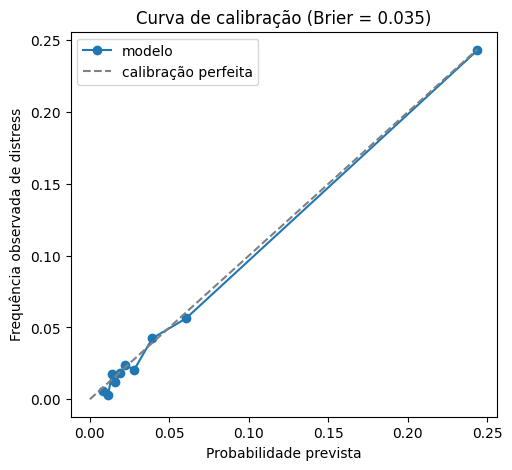

Brier score = 0.0348 (menor é melhor; abaixo da taxa-base ~0,04 indica boas probabilidades).


In [20]:
# Calibração: probabilidade prevista vs. frequência observada
pp, pt, brier = distress.curva_calibracao(res['teste'])
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(pp, pt, 'o-', label='modelo')
ax.plot([0, pp.max()], [0, pp.max()], '--', color='grey', label='calibração perfeita')
ax.set_xlabel('Probabilidade prevista'); ax.set_ylabel('Frequência observada de distress')
ax.set_title(f'Curva de calibração (Brier = {brier:.3f})'); ax.legend(); plt.show()
print(f'Brier score = {brier:.4f} (menor é melhor; abaixo da taxa-base ~0,04 indica boas probabilidades).')

,basileia_min,roe_min,taxa_base,auc_roc,ks
0,8.0,-20.0,0.070,0.835,0.533
1,8.0,-30.0,0.049,0.825,0.514
2,8.0,-40.0,0.039,0.836,0.525
3,10.5,-20.0,0.071,0.844,0.537
4,10.5,-30.0,0.050,0.832,0.521
5,10.5,-40.0,0.041,0.842,0.550
6,11.0,-20.0,0.073,0.845,0.539
7,11.0,-30.0,0.052,0.832,0.519
8,11.0,-40.0,0.043,0.843,0.553


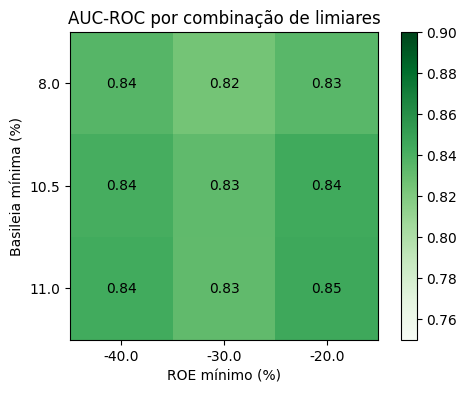

AUC ~0,83 e KS ~0,52 em toda a grade -> resultado robusto à escolha do corte.


In [21]:
# Sensibilidade: reestima o EWS numa grade de limiares (leva ~15s)
sens = distress.sensibilidade_limiares(ip)
display(sens.round(3))
piv = sens.pivot(index='basileia_min', columns='roe_min', values='auc_roc')
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(piv.values, cmap='Greens', vmin=0.75, vmax=0.90)
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f'{piv.values[i,j]:.2f}', ha='center', va='center')
ax.set_xlabel('ROE mínimo (%)'); ax.set_ylabel('Basileia mínima (%)')
ax.set_title('AUC-ROC por combinação de limiares'); fig.colorbar(im); plt.show()
print('AUC ~0,83 e KS ~0,52 em toda a grade -> resultado robusto à escolha do corte.')

In [22]:
# Watchlist: maior probabilidade de distress no trimestre atual
display(distress.watchlist(d, res, top=8))

,nome,prob_distress,basileia,roe,liquidez,eficiencia,ativo_total_mil,CodInst
0,COOPERATIVA DE CRÉDITO E INVESTIMENTO COM INTE...,0.969331,11.491471,-521.341400,59.971651,251.219879,1.885232e+06,53575491
1,COOPERATIVA DE ECONOMIA E CRÉDITO MÚTUO SERVID...,0.870221,29.454886,-174.064309,17.140763,325.403442,1.776368e+06,05591437
2,COOPERATIVA DE CRÉDITO DE LIVRE ADMISSÃO BURIT...,0.757426,12.738372,-44.275256,11.594435,132.889712,5.371428e+08,05247312
3,COOPERATIVA DE CRÉDITO CREDPLUS LTDA. - SICOOB...,0.745902,12.482287,-35.959923,29.402881,92.475879,7.884306e+08,25536764
4,COOPERATIVA DE CRÉDITO CLÁSSICA DOS EMPREGADOS...,0.640023,12.509534,-28.243268,8.149289,157.745259,8.117066e+07,33924028
5,COOPERATIVA DE CREDITO CREDIMOTA SICOOB CRED...,0.635009,12.306382,-43.706622,16.570651,206.079900,7.059835e+08,66788142
6,COOPERATIVA DE CRÉDITO DE LIVRE ADMISSÃO DO CE...,0.619773,12.859391,-45.958276,20.451258,225.461093,1.407762e+09,03326437
7,COOPERATIVA DE CRÉDITO DE LIVRE ADMISSÃO SICOO...,0.609921,12.501214,-76.906394,60.627167,301.358074,1.496711e+08,07946216


## 9. Etapa 9 — Grandes bancos COM Basileia

Combina o balanço (Olinda, individual) com a Basileia da visão prudencial
(portal), via *crosswalk* nominal, para os grandes bancos nos trimestres recentes
(2025+). Como 2025 já está sob o novo plano de contas (Res. CMN 4.966), o índice
usa apenas indicadores estáveis (sem eficiência). **Faz chamadas de rede**.

In [23]:
cap = portal.baixar_indices_capital(sessao=sessao)   # Basileia prudencial (portal)
periodos = sorted(cap.AnoMes.unique())
print('Trimestres com Basileia (portal):', periodos)

# Olinda tipo=3 para os mesmos períodos
def puxa(rel):
    ps = [ifdata.relatorio_largo(ifdata.baixar_valores(p, 3, rel, sessao=sessao)) for p in periodos]
    return pd.concat(ps, ignore_index=True)
gi = ind.construir_indicadores(puxa(1), puxa(2), puxa(4))
gi = gi.merge(nomes[['CodInst','nome']], on='CodInst', how='left')
gi['nome'] = gi['nome'].fillna(gi['CodInst'])
gi = portal.anexar_basileia(gi, cap, cfg['crosswalk_prudencial'])

cw = {str(k).zfill(8) for k in cfg['crosswalk_prudencial']}
# 2025+ tem quebra contábil na DRE (Res. CMN 4.966): a eficiência não é
# comparável, então o snapshot recente usa só indicadores estáveis.
gi = gi.drop(columns=['eficiencia'], errors='ignore')
gp = score.calcular_icr(score.padronizar(
        gi[gi.basileia.notna() & (gi.ativo_total_mil>=1e6)], cfg['indicadores'], cfg['padronizacao']),
        cfg['indicadores'], 'solidez')
up = gp.AnoMes.max()
colg = ['nome','ICR','basileia','alavancagem','roa','roe','liquidez']
display(gp[(gp.AnoMes==up) & gp.CodInst.isin(cw)].sort_values('ICR', ascending=False)[colg].round(2))

  portal 202603: 1320 instituições com Basileia


  portal 202512: 1341 instituições com Basileia


  portal 202509: 1359 instituições com Basileia


  portal 202506: 1352 instituições com Basileia


  portal 202503: 1351 instituições com Basileia
Trimestres com Basileia (portal): [np.int64(202503), np.int64(202506), np.int64(202509), np.int64(202512), np.int64(202603)]


,nome,ICR,basileia,alavancagem,roa,roe,liquidez
7020,NU PAGAMENTOS S.A. - INSTITUIÇÃO DE PAGAMENTO,-0.04,15.10,5.47,4.91,26.86,1.25
7654,BANCO VOTORANTIM S.A.,-0.19,15.01,11.41,1.32,15.01,35.41
7168,BANCO BTG PACTUAL S.A.,-0.19,15.91,8.82,2.78,24.54,63.99
7634,BANCO SAFRA S.A.,-0.20,17.35,15.51,1.46,22.62,46.65
7912,BANCO SANTANDER (BRASIL) S.A.,-0.29,15.15,12.48,1.27,15.79,44.31
7664,ITAÚ UNIBANCO S.A.,-0.29,14.77,13.39,1.83,24.46,46.94
7926,BANCO DO ESTADO DO RIO GRANDE DO SUL S.A.,-0.37,17.47,14.50,0.54,7.82,45.84
7666,BANCO BRADESCO S.A.,-0.53,14.90,11.10,1.04,11.59,39.55
6362,BANCO DO BRASIL S.A.,-0.56,14.23,13.37,0.49,6.50,40.48
6377,CAIXA ECONOMICA FEDERAL,-0.62,15.13,20.38,0.53,10.77,30.84


## 10. Etapa 10 — Diagnóstico (checagens de sanidade)

Verificamos invariantes do pipeline. A checagem-chave é a **sazonalidade do
ROE**: se a anualização estivesse errada, a mediana do 4º trimestre seria ~metade
das demais. Para a auditoria completa (8 checagens), rode `python scripts/08_diagnostico.py`.

In [24]:
ip2 = ip.copy(); ip2['mes'] = ip2.AnoMes % 100
med = ip2.groupby('mes')['roe'].median()
razao = med.abs().max()/med.abs().min()
print('Mediana do ROE anualizado por trimestre:')
for m,v in med.items(): print(f'  T{m//3}: {v:.1f}%')
print(f'Razão máx/mín = {razao:.2f}  ->', 'OK (anualização correta)' if razao < 1.6 else 'PROBLEMA!')

Mediana do ROE anualizado por trimestre:
  T1: 10.4%
  T2: 11.2%
  T3: 11.8%
  T4: 12.4%
Razão máx/mín = 1.19  -> OK (anualização correta)


## 11. Etapa 11 — ICR 2.0 (IFRS 9, 2025+)

A reforma contábil de 2025 (Res. CMN 4.966) trouxe a **Perda Esperada** (IFRS 9),
que permite cobrir a dimensão **A (Asset quality)** do CAMELS — ausente no índice
de 2016–2024 — via **custo de risco** (perda esperada de crédito ÷ ativo). Aqui
montamos o **ICR 2.0** (CAMELS completo, 8 indicadores) e, em seguida, testamos se
as faixas do ICR de **2024** preveem o custo de risco **realizado em 2025**.
**Faz chamadas de rede** (portal + Olinda).

In [25]:
from icr import icr2
ind_cfg2 = cfg['icr2_indicadores']            # 8 indicadores (CAMELS completo)
cap2 = portal.baixar_indices_capital(sessao=sessao)
pers = sorted(int(p) for p in cap2.AnoMes.unique())
print('Trimestres IFRS-9:', pers)

# puxa rel 1/2/4 (tipo 3) uma vez por período e reaproveita
raw25 = {p: tuple(ifdata.relatorio_largo(ifdata.baixar_valores(p, 3, rel, sessao=sessao))
                  for rel in (1, 2, 4)) for p in pers}
pan2 = pd.concat([icr2.construir_indicadores_ifrs9(*raw25[p]) for p in pers], ignore_index=True)
pan2 = pan2.merge(nomes[['CodInst','nome']], on='CodInst', how='left')
pan2['nome'] = pan2['nome'].fillna(pan2['CodInst'])
pan2 = portal.anexar_basileia(pan2, cap2, cfg['crosswalk_prudencial'])
pan2 = pan2[(pan2.basileia.notna()) & (pan2.ativo_total_mil.fillna(0) >= 1e6)].reset_index(drop=True)

icr2df = score.calcular_icr(score.padronizar(pan2, ind_cfg2, cfg['padronizacao']), ind_cfg2, 'solidez')
icr2df = score.classificar_risco(icr2df, cfg['zona_risco']['percentil'], 'solidez')
ult2 = int(icr2df.AnoMes.max()); cw2 = {str(k).zfill(8) for k in cfg['crosswalk_prudencial']}
gr = icr2df[(icr2df.AnoMes == ult2) & icr2df.CodInst.isin(cw2)].sort_values('ICR', ascending=False)
print(f'ICR 2.0 — grandes bancos ({ult2}):')
display(gr[['nome','ICR','faixa','basileia','custo_risco','roe','liquidez','eficiencia']].round(2))
print('Importância dos indicadores (o custo de risco entra no top-3):')
display(expl.importancia_por_contribuicao(icr2df, ind_cfg2).round(3))

  portal 202603: 1320 instituições com Basileia


  portal 202512: 1341 instituições com Basileia


  portal 202509: 1359 instituições com Basileia


  portal 202506: 1352 instituições com Basileia


  portal 202503: 1351 instituições com Basileia
Trimestres IFRS-9: [202503, 202506, 202509, 202512, 202603]


ICR 2.0 — grandes bancos (202603):


,nome,ICR,faixa,basileia,custo_risco,roe,liquidez,eficiencia
3744,BANCO SAFRA S.A.,0.14,Adequado,17.35,0.32,22.62,46.65,18.37
3623,BANCO BTG PACTUAL S.A.,0.14,Adequado,15.91,0.01,24.54,63.99,34.31
3550,NU PAGAMENTOS S.A. - INSTITUIÇÃO DE PAGAMENTO,0.06,Adequado,15.10,0.00,26.86,1.25,68.31
3753,ITAÚ UNIBANCO S.A.,0.04,Adequado,14.77,0.80,24.46,46.94,20.94
3914,BANCO SANTANDER (BRASIL) S.A.,-0.00,Adequado,15.15,1.50,15.79,44.31,14.04
3749,BANCO VOTORANTIM S.A.,-0.03,Adequado,15.01,2.74,15.01,35.41,13.08
3923,BANCO DO ESTADO DO RIO GRANDE DO SUL S.A.,-0.07,Atenção,17.47,1.48,7.82,45.84,20.42
3754,BANCO BRADESCO S.A.,-0.21,Atenção,14.90,1.67,11.59,39.55,22.41
3168,CAIXA ECONOMICA FEDERAL,-0.23,Atenção,15.13,1.28,10.77,30.84,18.03
3160,BANCO DO BRASIL S.A.,-0.30,Atenção,14.23,2.92,6.50,40.48,15.89


Importância dos indicadores (o custo de risco entra no top-3):


,indicador,contrib_abs_media,contrib_media,importancia_pct
0,basileia,0.163,0.0,22.108
1,liquidez,0.119,-0.0,16.097
2,custo_risco,0.116,0.0,15.670
3,roa,0.075,-0.0,10.112
4,roe,0.073,-0.0,9.943
5,eficiencia,0.071,-0.0,9.586
6,alavancagem,0.061,0.0,8.276
7,imobilizacao,0.061,-0.0,8.208


n=1534 | Spearman(ICR 2024, custo de risco 2025) = -0.276  (esperado negativo)


C:\Users\ahmad\AppData\Local\Temp\ipykernel_60500\960817235.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = mv.groupby('faixa')['custo_risco_2025'].agg(['mean','median','count']).reindex(


,mean,median,count
faixa,,,
Crítico,2.339,1.492,381
Atenção,2.300,1.409,386
Adequado,1.733,1.064,382
Sólido,0.995,0.000,385


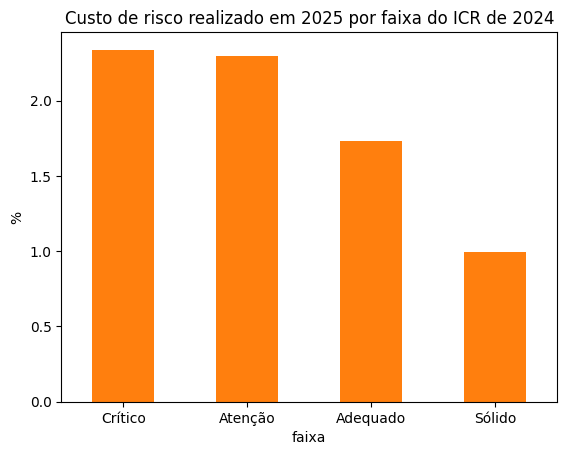

In [26]:
# Validação-loop: o ICR de 2024 (regime antigo, SEM provisão) prevê o custo de
# risco REALIZADO em 2025 (IFRS 9)?
cr25 = (pd.concat([icr2.custo_de_risco(raw25[p][0], raw25[p][2]) for p in pers])
        .groupby('CodInst')['custo_risco'].mean().rename('custo_risco_2025'))
old = pd.read_parquet(dir_processed_painel('sistemico') / 'icr.parquet')
old24 = old[old.AnoMes == 202412][['CodInst','ICR','faixa']]
mv = old24.merge(cr25, on='CodInst', how='inner').dropna(subset=['ICR','custo_risco_2025'])
lo, hi = mv.custo_risco_2025.quantile([.01, .99]); mv = mv[mv.custo_risco_2025.between(lo, hi)]
print(f"n={len(mv)} | Spearman(ICR 2024, custo de risco 2025) = "
      f"{mv.ICR.corr(mv.custo_risco_2025, method='spearman'):.3f}  (esperado negativo)")
g = mv.groupby('faixa')['custo_risco_2025'].agg(['mean','median','count']).reindex(
        ['Crítico','Atenção','Adequado','Sólido'])
display(g.round(3))
g['mean'].plot.bar(color='tab:orange', rot=0,
    title='Custo de risco realizado em 2025 por faixa do ICR de 2024'); plt.ylabel('%'); plt.show()

### 11.1 Poder preditivo prospectivo do ICR 2.0 — suite completo (§5.4)

O próprio **ICR 2.0**, usado como escore (sem reestimação), prevê *distress*
(Basileia < 10,5% ou ROE < −30%) no **trimestre seguinte**? Reproduzimos aqui, para
2025+, **todas as métricas** do EWS de 2024: AUC-ROC, AUC-PR, **KS**, matriz de
confusão, F1, *Brier* (calibração fora do tempo), o **painel completo** e a
**sensibilidade aos limiares**.

In [27]:
# §5.4 — suite COMPLETO (mesmas métricas do EWS de 2024): ICR 2.0 como escore -> distress em t+1
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             confusion_matrix, precision_recall_fscore_support, brier_score_loss)
from sklearn.linear_model import LogisticRegression
ev = []
pers = sorted(int(p) for p in icr2df.AnoMes.unique())
for t, t1 in zip(pers[:-1], pers[1:]):
    a = icr2df[icr2df.AnoMes==t][['CodInst','ICR']].rename(columns={'ICR':'ICRt'})
    b = icr2df[icr2df.AnoMes==t1][['CodInst','basileia','roe']]
    m = a.merge(b, on='CodInst', how='inner').dropna(subset=['ICRt']); m['t'] = t
    m['distress'] = ((m.basileia<10.5)|(m.roe<-30)).astype(int)
    ev.append(m)
ev = pd.concat(ev, ignore_index=True)
y = ev.distress.values; risk = -ev.ICRt.values
fpr, tpr, thr = roc_curve(y, risk); ks = (tpr-fpr).max(); thr_y = thr[(tpr-fpr).argmax()]
pred = (risk >= thr_y).astype(int)
prec, rec, f1, _ = precision_recall_fscore_support(y, pred, average='binary', zero_division=0)
# Brier: calibracao logistica FORA DO TEMPO (treina 3 primeiros pares, testa o ultimo)
tt = sorted(ev.t.unique()); tr = ev[ev.t.isin(tt[:-1])]; te = ev[ev.t==tt[-1]]
lr = LogisticRegression().fit((-tr.ICRt).values.reshape(-1,1), tr.distress.values)
brier = brier_score_loss(te.distress.values, lr.predict_proba((-te.ICRt).values.reshape(-1,1))[:,1])
print(f'ICR 2.0(t) -> distress(t+1): n={len(y)}, eventos={y.sum()} ({100*y.mean():.1f}%)')
print(f'AUC-ROC={roc_auc_score(y,risk):.3f}  AUC-PR={average_precision_score(y,risk):.3f}  '
      f'KS={ks:.3f}  |  Brier (calibr. fora do tempo)={brier:.3f}')
print(f'Matriz de confusao (Youden)={confusion_matrix(y,pred).tolist()}  prec={prec:.3f} rec={rec:.3f} F1={f1:.3f}')
print('Estabilidade por trimestre inicial: ' + ' | '.join(
      f'{t} AUC={roc_auc_score(gg.distress,-gg.ICRt):.3f}' for t,gg in ev.groupby('t') if gg.distress.sum()>0))

ICR 2.0(t) -> distress(t+1): n=3138, eventos=98 (3.1%)
AUC-ROC=0.871  AUC-PR=0.335  KS=0.597  |  Brier (calibr. fora do tempo)=0.035
Matriz de confusao (Youden)=[[2682, 358], [28, 70]]  prec=0.164 rec=0.714 F1=0.266
Estabilidade por trimestre inicial: 202503 AUC=0.933 | 202506 AUC=0.821 | 202509 AUC=0.903 | 202512 AUC=0.865

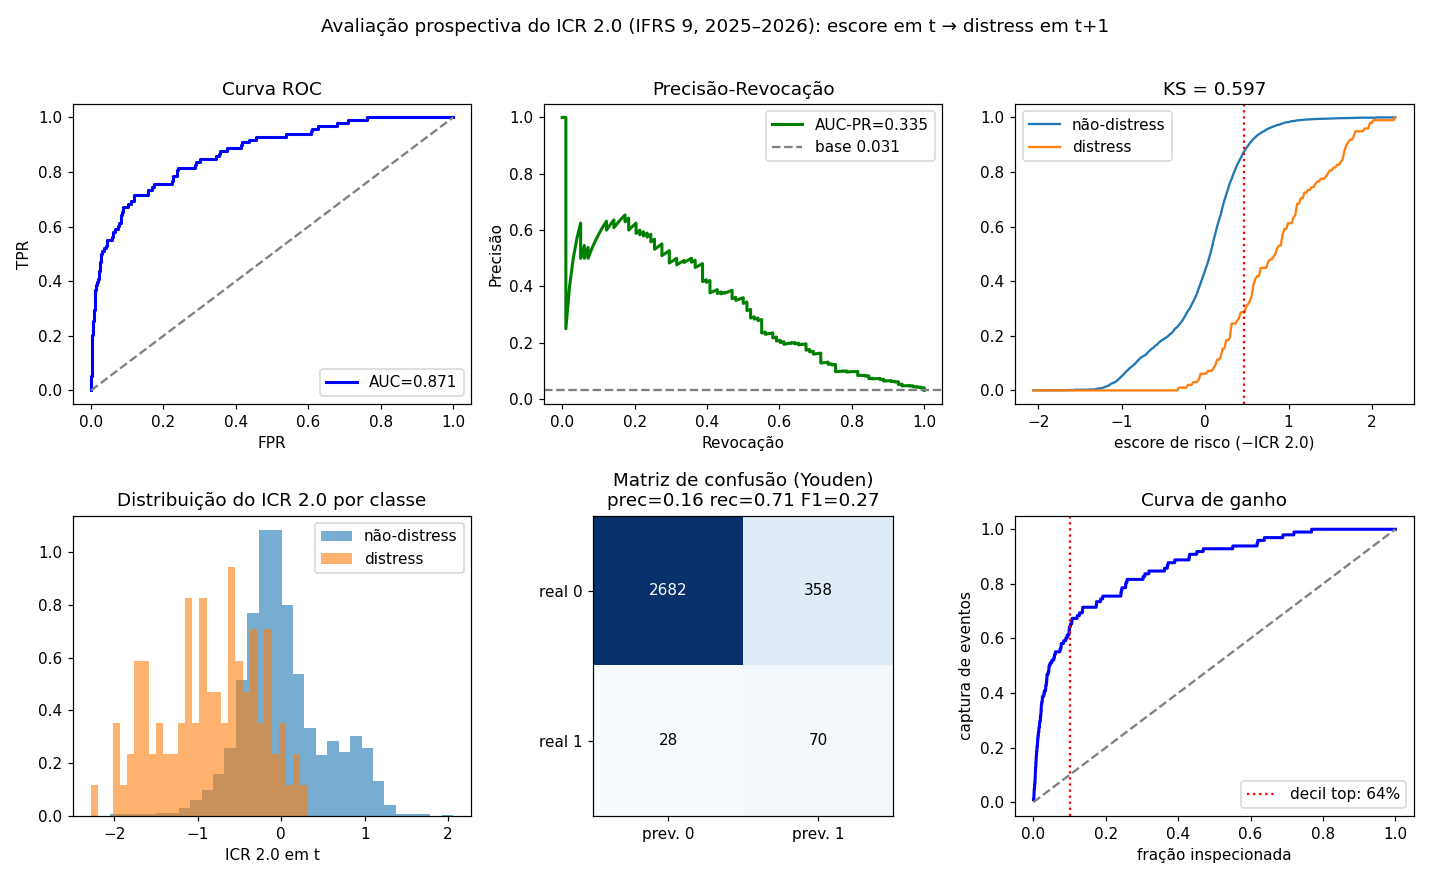

In [28]:
# Painel completo de avaliacao (mesma forma da Figura 3 do EWS de 2024) = Figura 7 do artigo
from sklearn.metrics import precision_recall_curve
prc_p, prc_r, _ = precision_recall_curve(y, risk)
cm = confusion_matrix(y, pred)
o = pd.DataFrame({'y':y,'r':risk}).sort_values('r',ascending=False).reset_index(drop=True)
frac = np.arange(1,len(o)+1)/len(o); cap = np.cumsum(o.y.values)/o.y.sum()
xs = np.linspace(risk.min(),risk.max(),200)
cpos = np.array([(risk[y==1]<=v).mean() for v in xs]); cneg = np.array([(risk[y==0]<=v).mean() for v in xs])
fig, ax = plt.subplots(2,3,figsize=(13,8))
ax[0,0].plot(fpr,tpr,'b',lw=2,label=f'AUC={roc_auc_score(y,risk):.3f}'); ax[0,0].plot([0,1],[0,1],'--',c='gray'); ax[0,0].set_title('Curva ROC'); ax[0,0].legend(loc='lower right')
ax[0,1].plot(prc_r,prc_p,'g',lw=2); ax[0,1].axhline(y.mean(),ls='--',c='gray'); ax[0,1].set_title(f'Precisao-Revocacao (AUC-PR={average_precision_score(y,risk):.3f})')
ax[0,2].plot(xs,cneg,label='nao-distress'); ax[0,2].plot(xs,cpos,label='distress'); ax[0,2].set_title(f'KS = {ks:.3f}'); ax[0,2].legend()
ax[1,0].hist(ev.ICRt[y==0],bins=30,alpha=.6,density=True,label='nao-distress'); ax[1,0].hist(ev.ICRt[y==1],bins=30,alpha=.6,density=True,label='distress'); ax[1,0].set_title('Distribuicao do ICR 2.0 por classe'); ax[1,0].legend()
ax[1,1].imshow(cm,cmap='Blues'); ax[1,1].set_title(f'Matriz de confusao (Youden)\nprec={prec:.2f} rec={rec:.2f} F1={f1:.2f}')
for (i,j),v in np.ndenumerate(cm): ax[1,1].text(j,i,str(v),ha='center',va='center')
ax[1,2].plot(frac,cap,'b',lw=2); ax[1,2].plot([0,1],[0,1],'--',c='gray'); ax[1,2].axvline(.1,ls=':',c='r',label=f'decil top: {100*cap[len(o)//10]:.0f}%'); ax[1,2].set_title('Curva de ganho'); ax[1,2].legend(loc='lower right')
fig.suptitle('Avaliacao prospectiva do ICR 2.0 (IFRS 9, 2025-2026): escore em t -> distress em t+1')
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()

In [29]:
# Sensibilidade aos limiares (Tabela 10) — reestima o rotulo de distress e reavalia
def _pares(bmin, rmin):
    rows = []
    for t, t1 in zip(pers[:-1], pers[1:]):
        a = icr2df[icr2df.AnoMes==t][['CodInst','ICR']].rename(columns={'ICR':'ICRt'})
        b = icr2df[icr2df.AnoMes==t1][['CodInst','basileia','roe']]
        mm = a.merge(b, on='CodInst', how='inner').dropna(subset=['ICRt'])
        mm['distress'] = ((mm.basileia<bmin)|(mm.roe<rmin)).astype(int); rows.append(mm)
    return pd.concat(rows, ignore_index=True)
sens = []
for bm in (8.0, 10.5, 11.0):
    for rm in (-20., -30., -40.):
        e = _pares(bm, rm); yy = e.distress.values; rr = -e.ICRt.values
        f2, t2, _ = roc_curve(yy, rr)
        sens.append({'basileia_min':bm,'roe_min':rm,'taxa_base':round(yy.mean(),3),
                     'auc_roc':round(roc_auc_score(yy,rr),3),'ks':round((t2-f2).max(),3)})
print('AUC ~0,87 e KS ~0,58-0,63 em toda a grade -> robusto a definicao de distress.')
display(pd.DataFrame(sens))

AUC ~0,87 e KS ~0,58-0,63 em toda a grade -> robusto a definicao de distress.


   basileia_min  roe_min  taxa_base  auc_roc     ks
0           8.0    -20.0      0.043    0.871  0.580
1           8.0    -30.0      0.031    0.870  0.593
2           8.0    -40.0      0.024    0.876  0.635
3          10.5    -20.0      0.043    0.871  0.580
4          10.5    -30.0      0.031    0.871  0.597
5          10.5    -40.0      0.025    0.878  0.632
6          11.0    -20.0      0.044    0.867  0.575
7          11.0    -30.0      0.032    0.866  0.589
8          11.0    -40.0      0.025    0.872  0.623

In [30]:
# §5.5 — importancia das variaveis nos DOIS modelos de alerta precoce (EWS 2024 vs 2025)
from sklearn.ensemble import GradientBoostingClassifier
FE = ['basileia','alavancagem','roa','roe','imobilizacao','liquidez','eficiencia','custo_risco']
pr = []
for t, t1 in zip(pers[:-1], pers[1:]):
    a = icr2df[icr2df.AnoMes==t][['CodInst']+FE]
    b = icr2df[icr2df.AnoMes==t1][['CodInst','basileia','roe']].rename(columns={'basileia':'b1','roe':'r1'})
    mm = a.merge(b, on='CodInst', how='inner').dropna(subset=FE)
    mm['distress'] = ((mm.b1<10.5)|(mm.r1<-30)).astype(int); pr.append(mm)
evc = pd.concat(pr, ignore_index=True)
gcmp = GradientBoostingClassifier(random_state=42).fit(evc[FE].values, evc.distress.values)
imp24 = pd.read_csv(dir_processed_painel('sistemico').parent/'distress_importancias.csv')
cmp = (pd.DataFrame({'feature':FE,'ews_2025':gcmp.feature_importances_})
       .merge(imp24.rename(columns={'importancia':'ews_2024'}), on='feature', how='left'))
cmp['ews_2024'] = cmp.ews_2024.fillna(0.0)
print('ROE domina nos dois regimes; custo de risco (novo) tem peso preditivo modesto:')
display(cmp.sort_values('ews_2024', ascending=False).round(3))

ROE domina nos dois regimes; custo de risco (novo) tem peso preditivo modesto:


      feature  ews_2025  ews_2024
3         roe     0.462     0.551
2         roa     0.094     0.119
6  eficiencia     0.079     0.088
0    basileia     0.120     0.075
4 imobilizacao    0.113     0.068
5    liquidez     0.048     0.063
1 alavancagem     0.030     0.036
7 custo_risco     0.053     0.000

---
**Fim.** Você percorreu as **11 etapas**: da coleta pública à validação em quatro
dimensões (instituições, tempo, macro, mercado), à explicabilidade, ao modelo de
alerta precoce (com avaliação completa, calibração e sensibilidade), à auditoria e à
**extensão IFRS 9 (ICR 2.0)** — com o mesmo suite de métricas para 2025+ (AUC, KS,
matriz de confusão, Brier e sensibilidade). Para produção, os scripts `01`–`09`
reproduzem tudo; para análise dos resultados já salvos, veja `notebooks/01_analise.ipynb`.